# Modelagem, clusters e aplicação

Pipeline Scikit-learn, comparação de algoritmos, SHAP, clusterização e risco de metas futuras.
Relatórios: `reports/02_clusters_e_metas_futuras.md` e `reports/03_modelagem.md`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..')
print(pd.read_csv(ROOT / 'reports' / 'metricas_modelos.csv').to_string(index=False))

                modelo  accuracy  precision  recall     f1  roc_auc  pr_auc  cv_f1
  dummy_mais_frequente    0.5330     0.0000  0.0000 0.0000   0.5000  0.4670    NaN
   regressao_logistica    0.7096     0.7126  0.6339 0.6710   0.7936  0.7782 0.6498
         random_forest    0.7068     0.7146  0.6196 0.6637   0.7994  0.7823 0.6398
hist_gradient_boosting    0.7135     0.7133  0.6462 0.6781   0.7972  0.7811 0.6554


## Modelo oficial: HistGradientBoosting

F1 0,678 e ROC-AUC 0,80 no teste. Dummy tem F1 0 na classe de risco. O SHAP aponta a meta estadual como o fator de maior impacto.

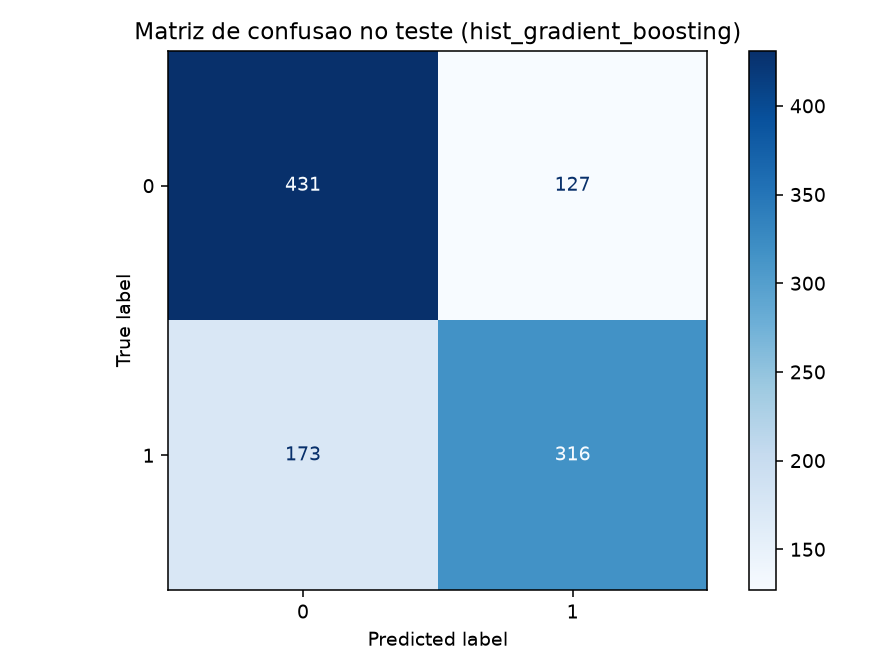

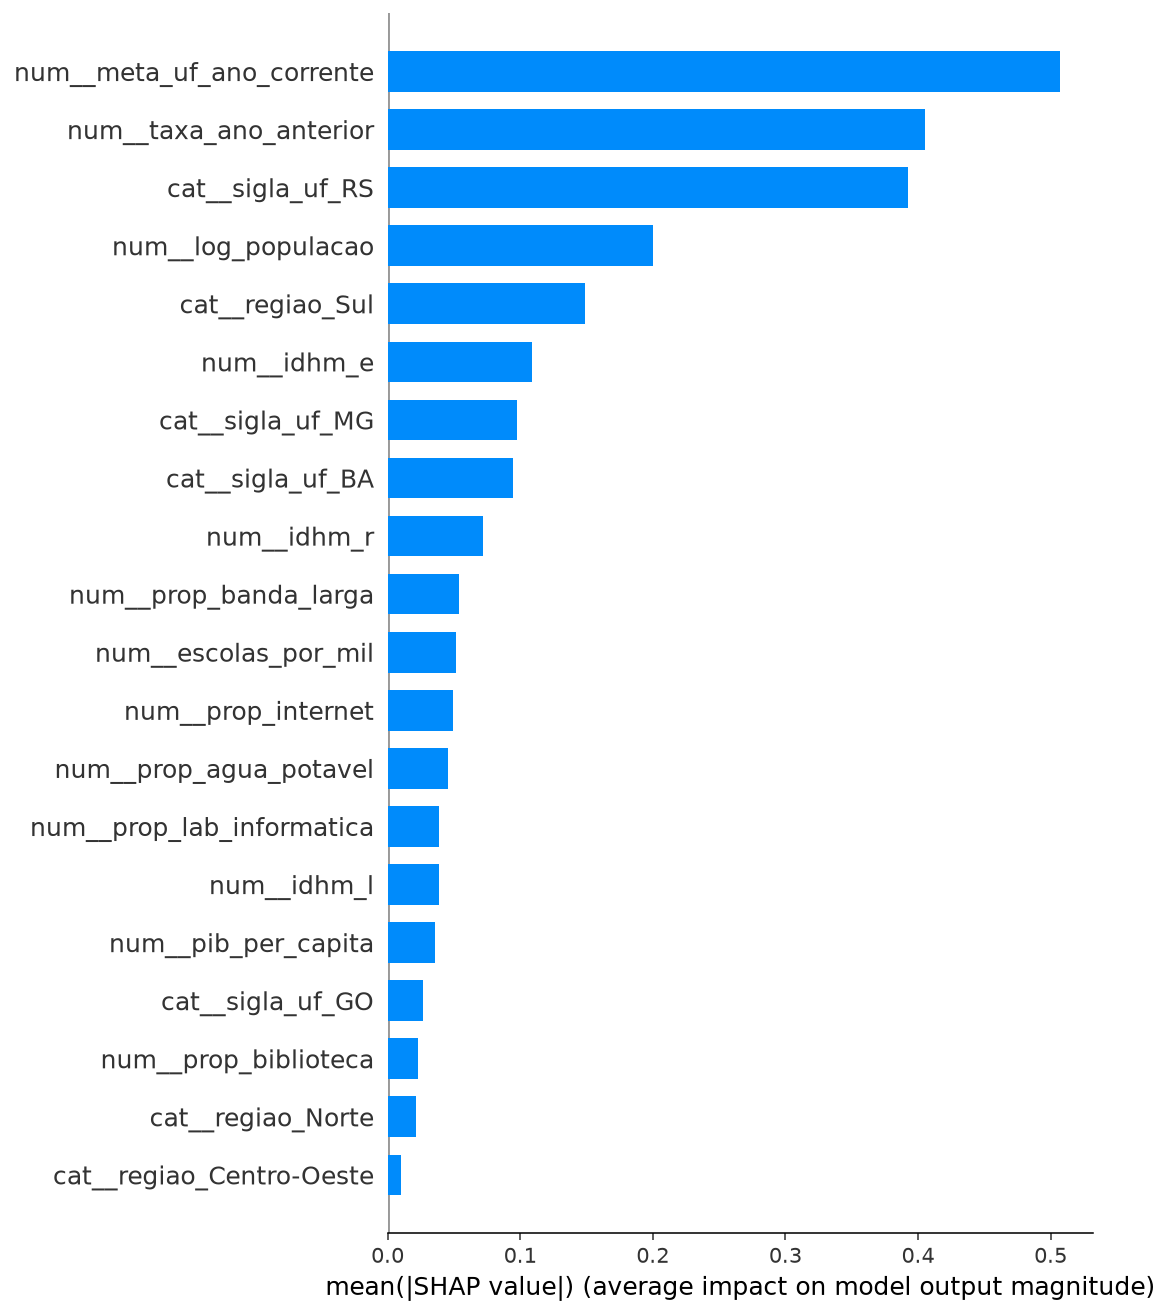

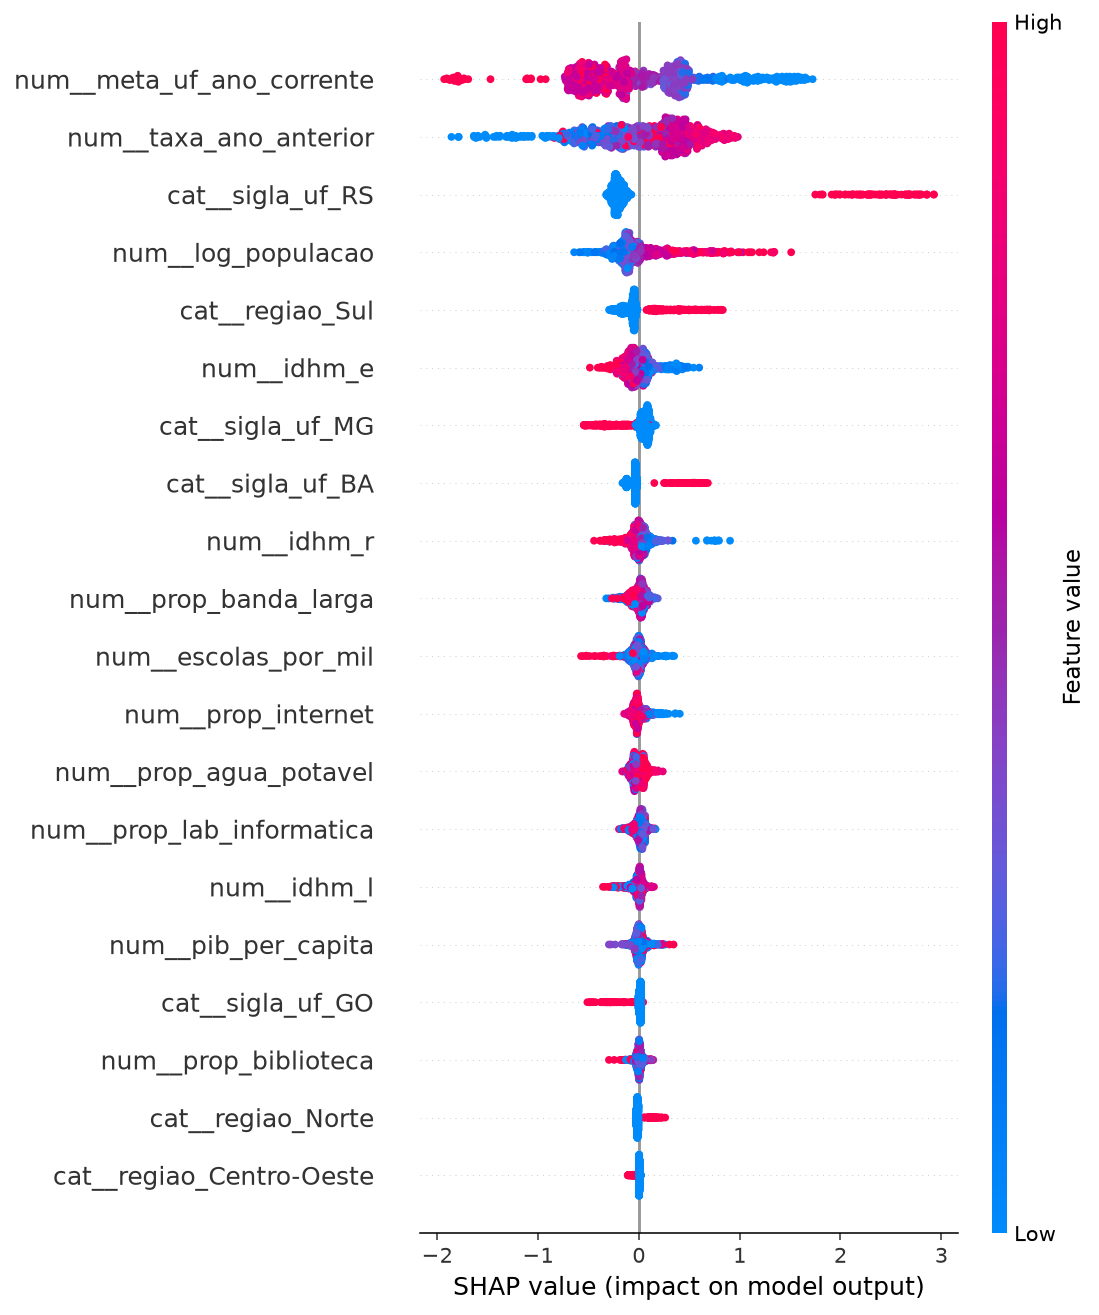

In [2]:
display(Image(ROOT / 'images' / 'modelagem' / '01_matriz_confusao.png'))
display(Image(ROOT / 'images' / 'modelagem' / '03_shap_bar.png'))
display(Image(ROOT / 'images' / 'modelagem' / '02_shap_summary.png'))

In [3]:
shap = pd.read_csv(ROOT / 'reports' / 'shap_importancia.csv')
shap.columns = ['feature', 'shap_abs']
shap.head(10)

,feature,shap_abs
0,num__meta_uf_ano_corrente,0.506751
1,num__taxa_ano_anterior,0.404987
2,cat__sigla_uf_RS,0.392664
3,num__log_populacao,0.200206
4,cat__regiao_Sul,0.148678
5,num__idhm_e,0.109222
6,cat__sigla_uf_MG,0.097699
7,cat__sigla_uf_BA,0.094815
8,num__idhm_r,0.071754
9,num__prop_banda_larga,0.053488


## Padrões semelhantes e metas futuras

K-Means K=6: cinco clusters são as regiões; o Nordeste se parte em baixa e alta taxa.
Persistência da taxa 2024: 56% abaixo da meta 2025 e 79% abaixo da de 2030.

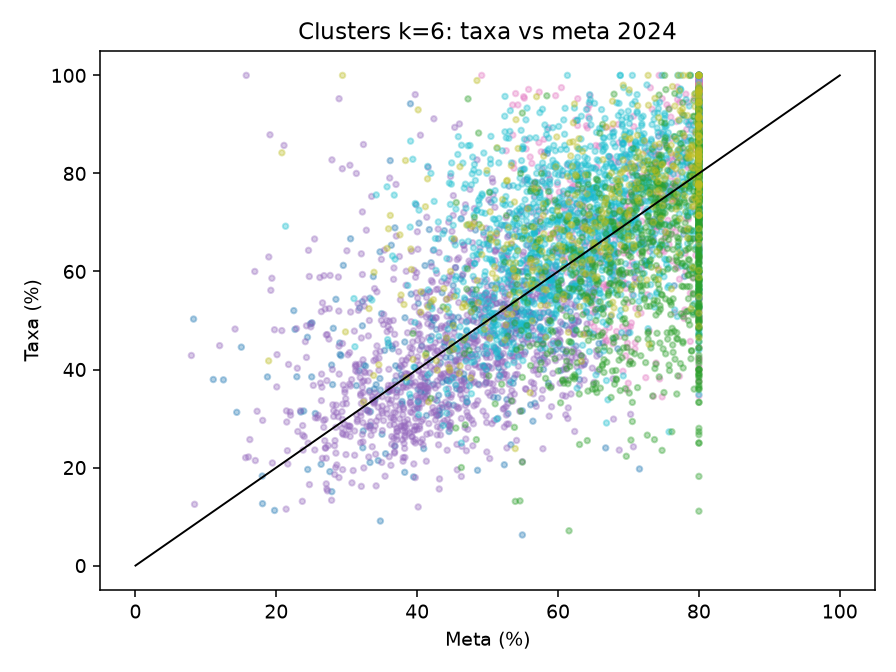

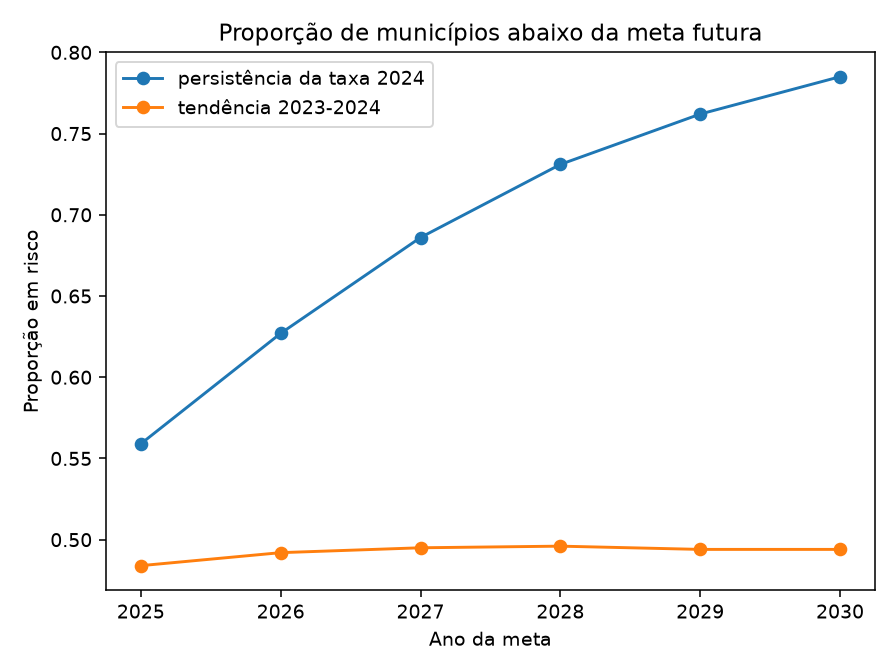

,ano_meta,n,prop_risco_persistencia,prop_risco_tendencia,meta_media
0,2025,5232,0.559,0.484,65.44
1,2026,5232,0.627,0.492,68.71
2,2027,5232,0.686,0.495,71.88
3,2028,5232,0.731,0.496,74.86
4,2029,5232,0.762,0.494,77.58
5,2030,5232,0.785,0.494,80.00


In [4]:
display(Image(ROOT / 'images' / 'clusters' / '02_taxa_vs_meta_cluster.png'))
display(Image(ROOT / 'images' / 'metas_futuras' / '01_prop_risco_por_ano.png'))
pd.read_csv(ROOT / 'reports' / 'risco_metas_futuras_resumo.csv')

In [5]:
pd.read_csv(ROOT / 'reports' / 'ranking_risco_predito_top100.csv').head(10)

,id_municipio,sigla_uf,regiao,taxa_alfabetizacao,nao_atingiu_meta,proba_nao_atingiu
0,4309209,RS,Sul,41.0,1,0.981564
1,4323002,RS,Sul,38.9,1,0.980395
2,4322608,RS,Sul,59.2,1,0.978547
3,4308201,RS,Sul,59.6,1,0.978235
4,4302105,RS,Sul,50.8,1,0.977447
5,4317608,RS,Sul,61.7,1,0.976538
6,4322509,RS,Sul,38.1,1,0.976413
7,4320404,RS,Sul,50.7,1,0.976296
8,4304507,RS,Sul,51.7,1,0.976102
9,4310108,RS,Sul,49.6,1,0.975970
